# Task 3

## Calculating Logical Coupling and Visualization

This section computes the logical coupling between Python files in the repository based on their co-modification in commits since January 1, 2023. Non-Python files and `__init__.py` files are excluded from the analysis.

The top 10 most coupled file pairs are visualized using a network graph, where nodes represent files and edges indicate the strength of their coupling.

Analyzing repo...


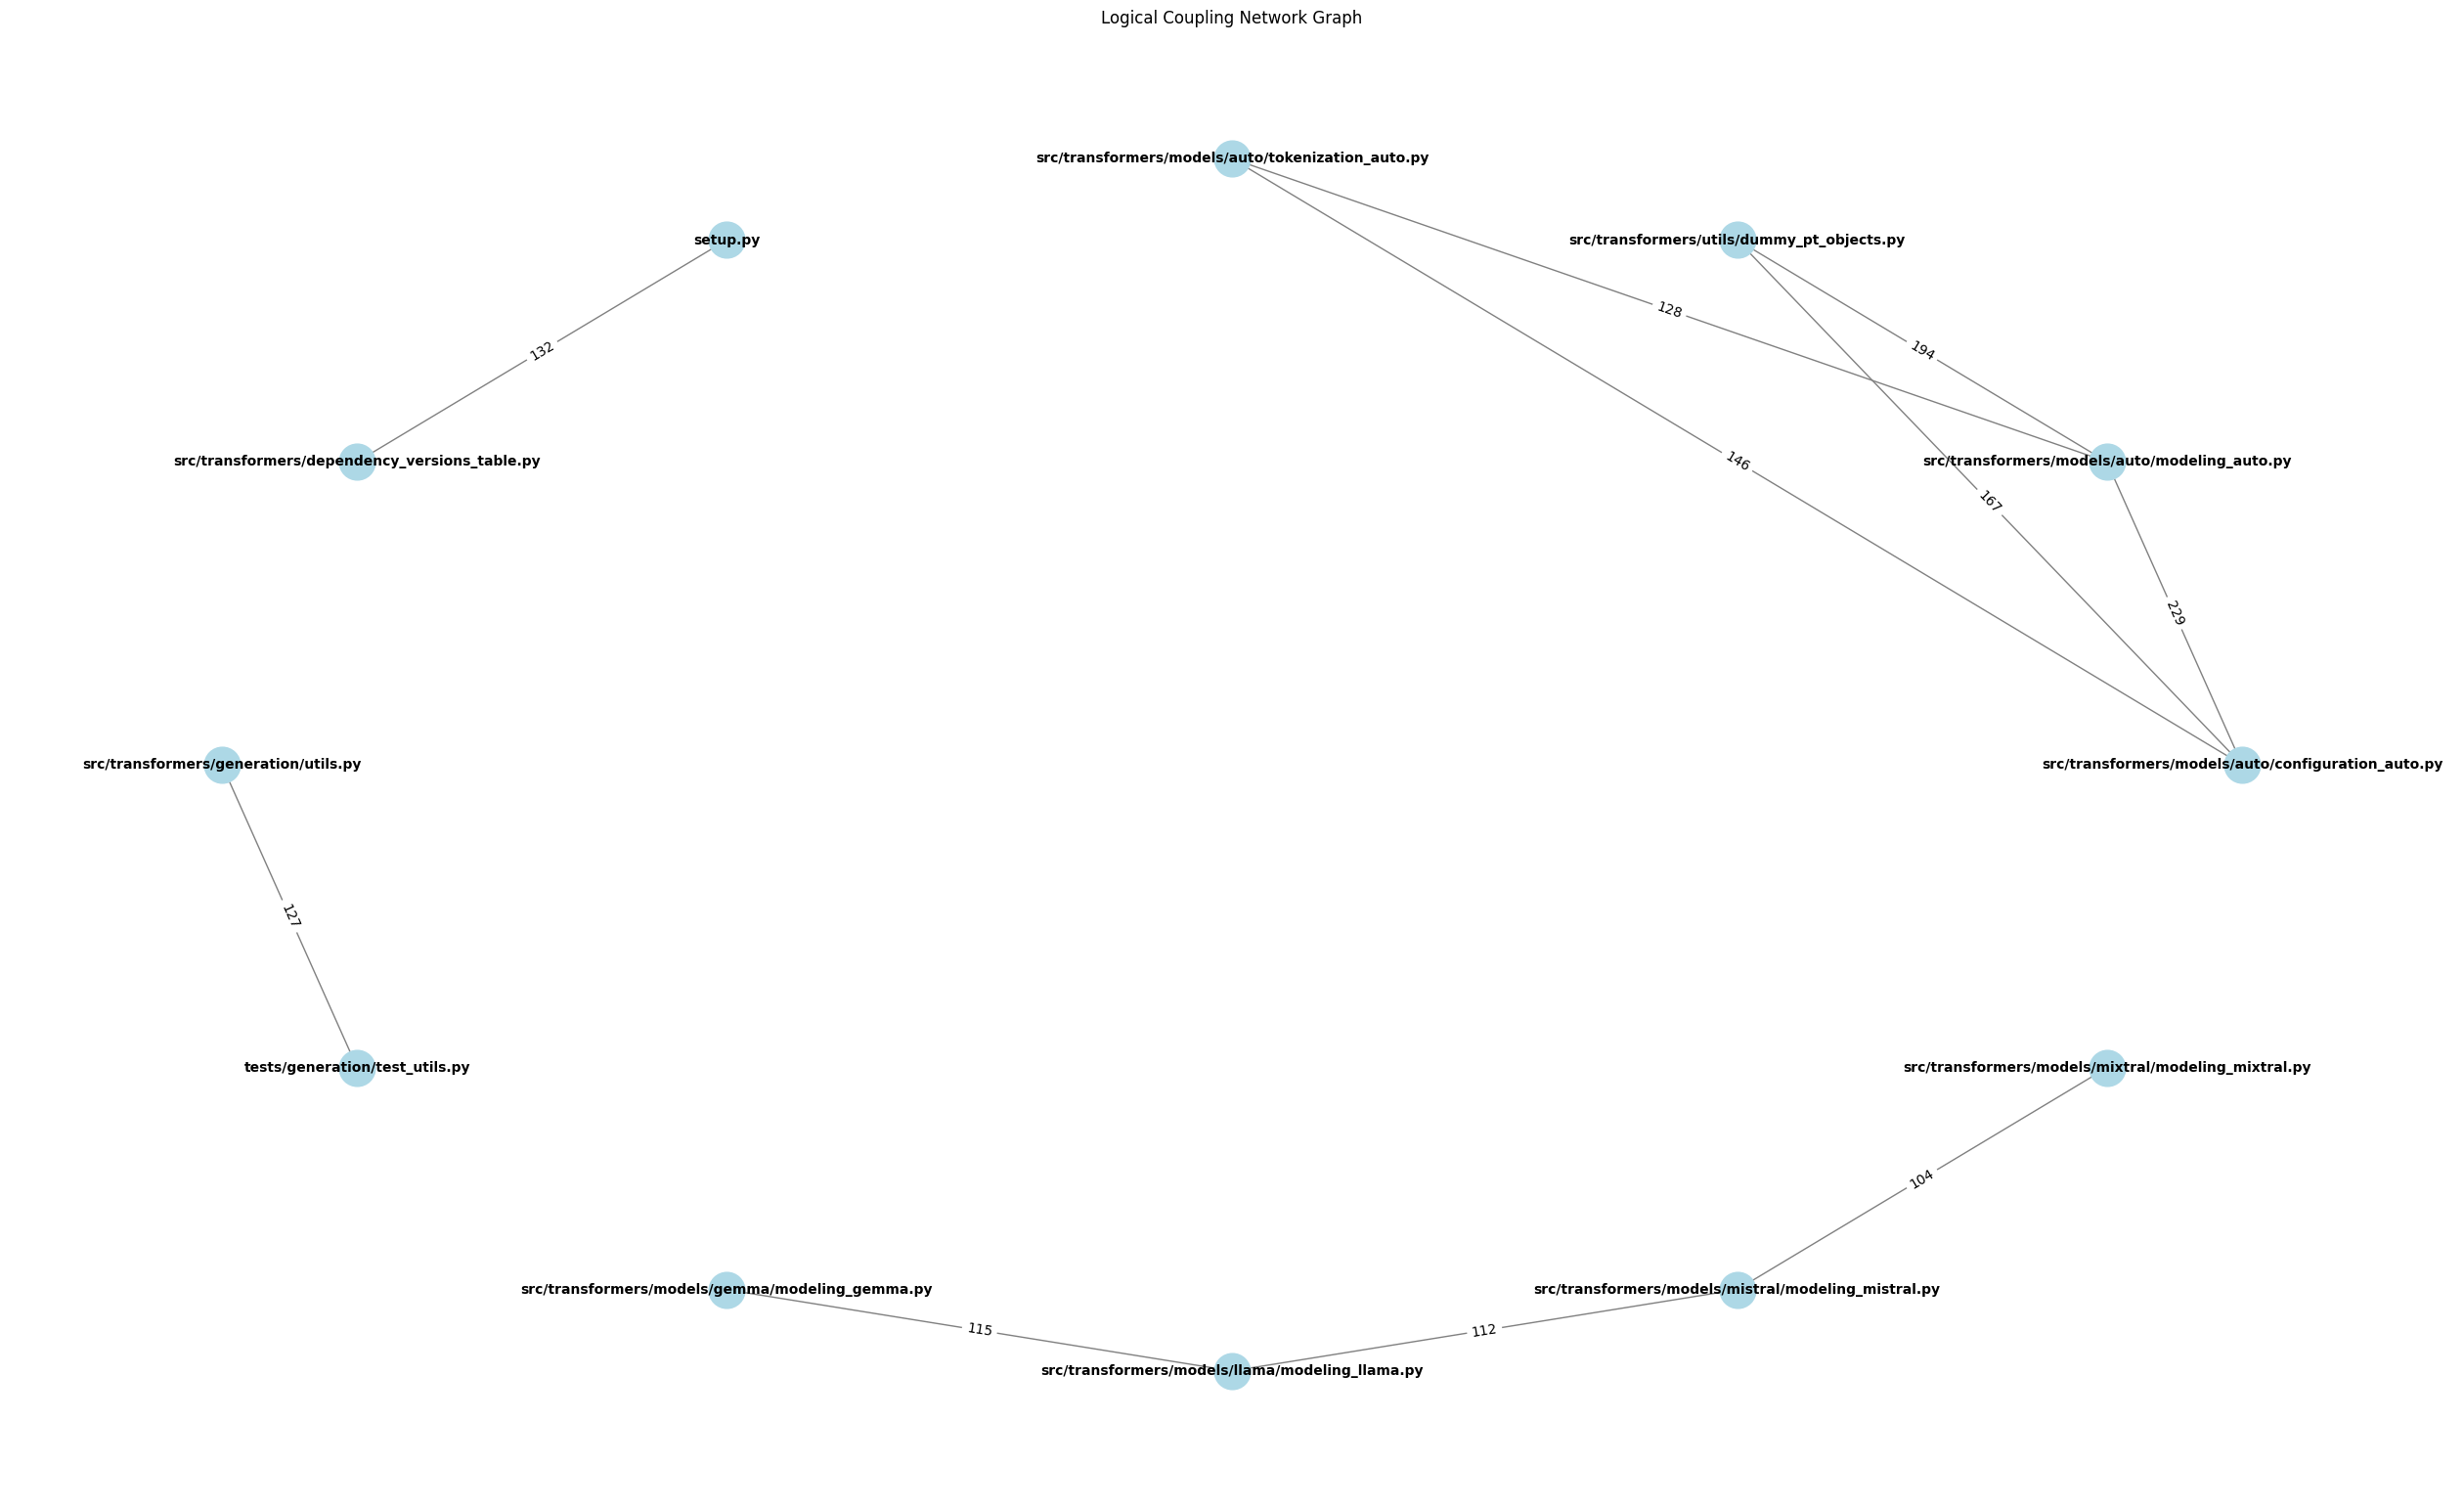

In [4]:
from datetime import datetime
from pydriller import Repository
from collections import Counter
import itertools
import os
from utils import plot_network_graph

REPOSITORY = os.environ.get("REPOSITORY_PATH")
if REPOSITORY is None:
    raise ValueError("Please source the setup.sh script or set the REPOSITORY_PATH environment variable to the local path of the cloned repository.")

DATE = datetime(2023, 1, 1)

def calculate_logical_coupling(repository, since_date):
    print("Analyzing repo...")
    file_pair_coupling = Counter()

    for commit in Repository(repository, since=since_date).traverse_commits():
        # Consider only Python files for coupling analysis, __init__.py files are excluded
        modified_files = [
            file.new_path for file in commit.modified_files
            if file.new_path and file.new_path.endswith('.py') and
               os.path.basename(file.new_path) != "__init__.py"
        ]
        # Commit requires at least two modified files to form a pair
        if len(modified_files) < 2:
            continue

        file_pairs = itertools.combinations(modified_files, 2)
        file_pair_coupling.update([tuple(sorted(pair)) for pair in file_pairs])

    return file_pair_coupling

calculated_coupling = calculate_logical_coupling(REPOSITORY, DATE) # This might take a while
top_10_pairs = calculated_coupling.most_common(10)
top_10_pairs = [(pair[0], pair[1], count) for pair, count in top_10_pairs]

plot_network_graph(top_10_pairs, "TASK3_logical_coupling.png", (25, 15))


## Analyzing Coupling Between Test and Non-Test Files

This section computes the logical coupling between test files (files starting with `test_`) and non-test Python files in the repository based on their co-modification in commits since January 1, 2023. Non-Python files and `__init__.py` files are excluded from the analysis.

The top 10 most coupled file pairs are visualized using a network graph, where nodes represent files and edges indicate the strength of their coupling.


Analyzing repo...


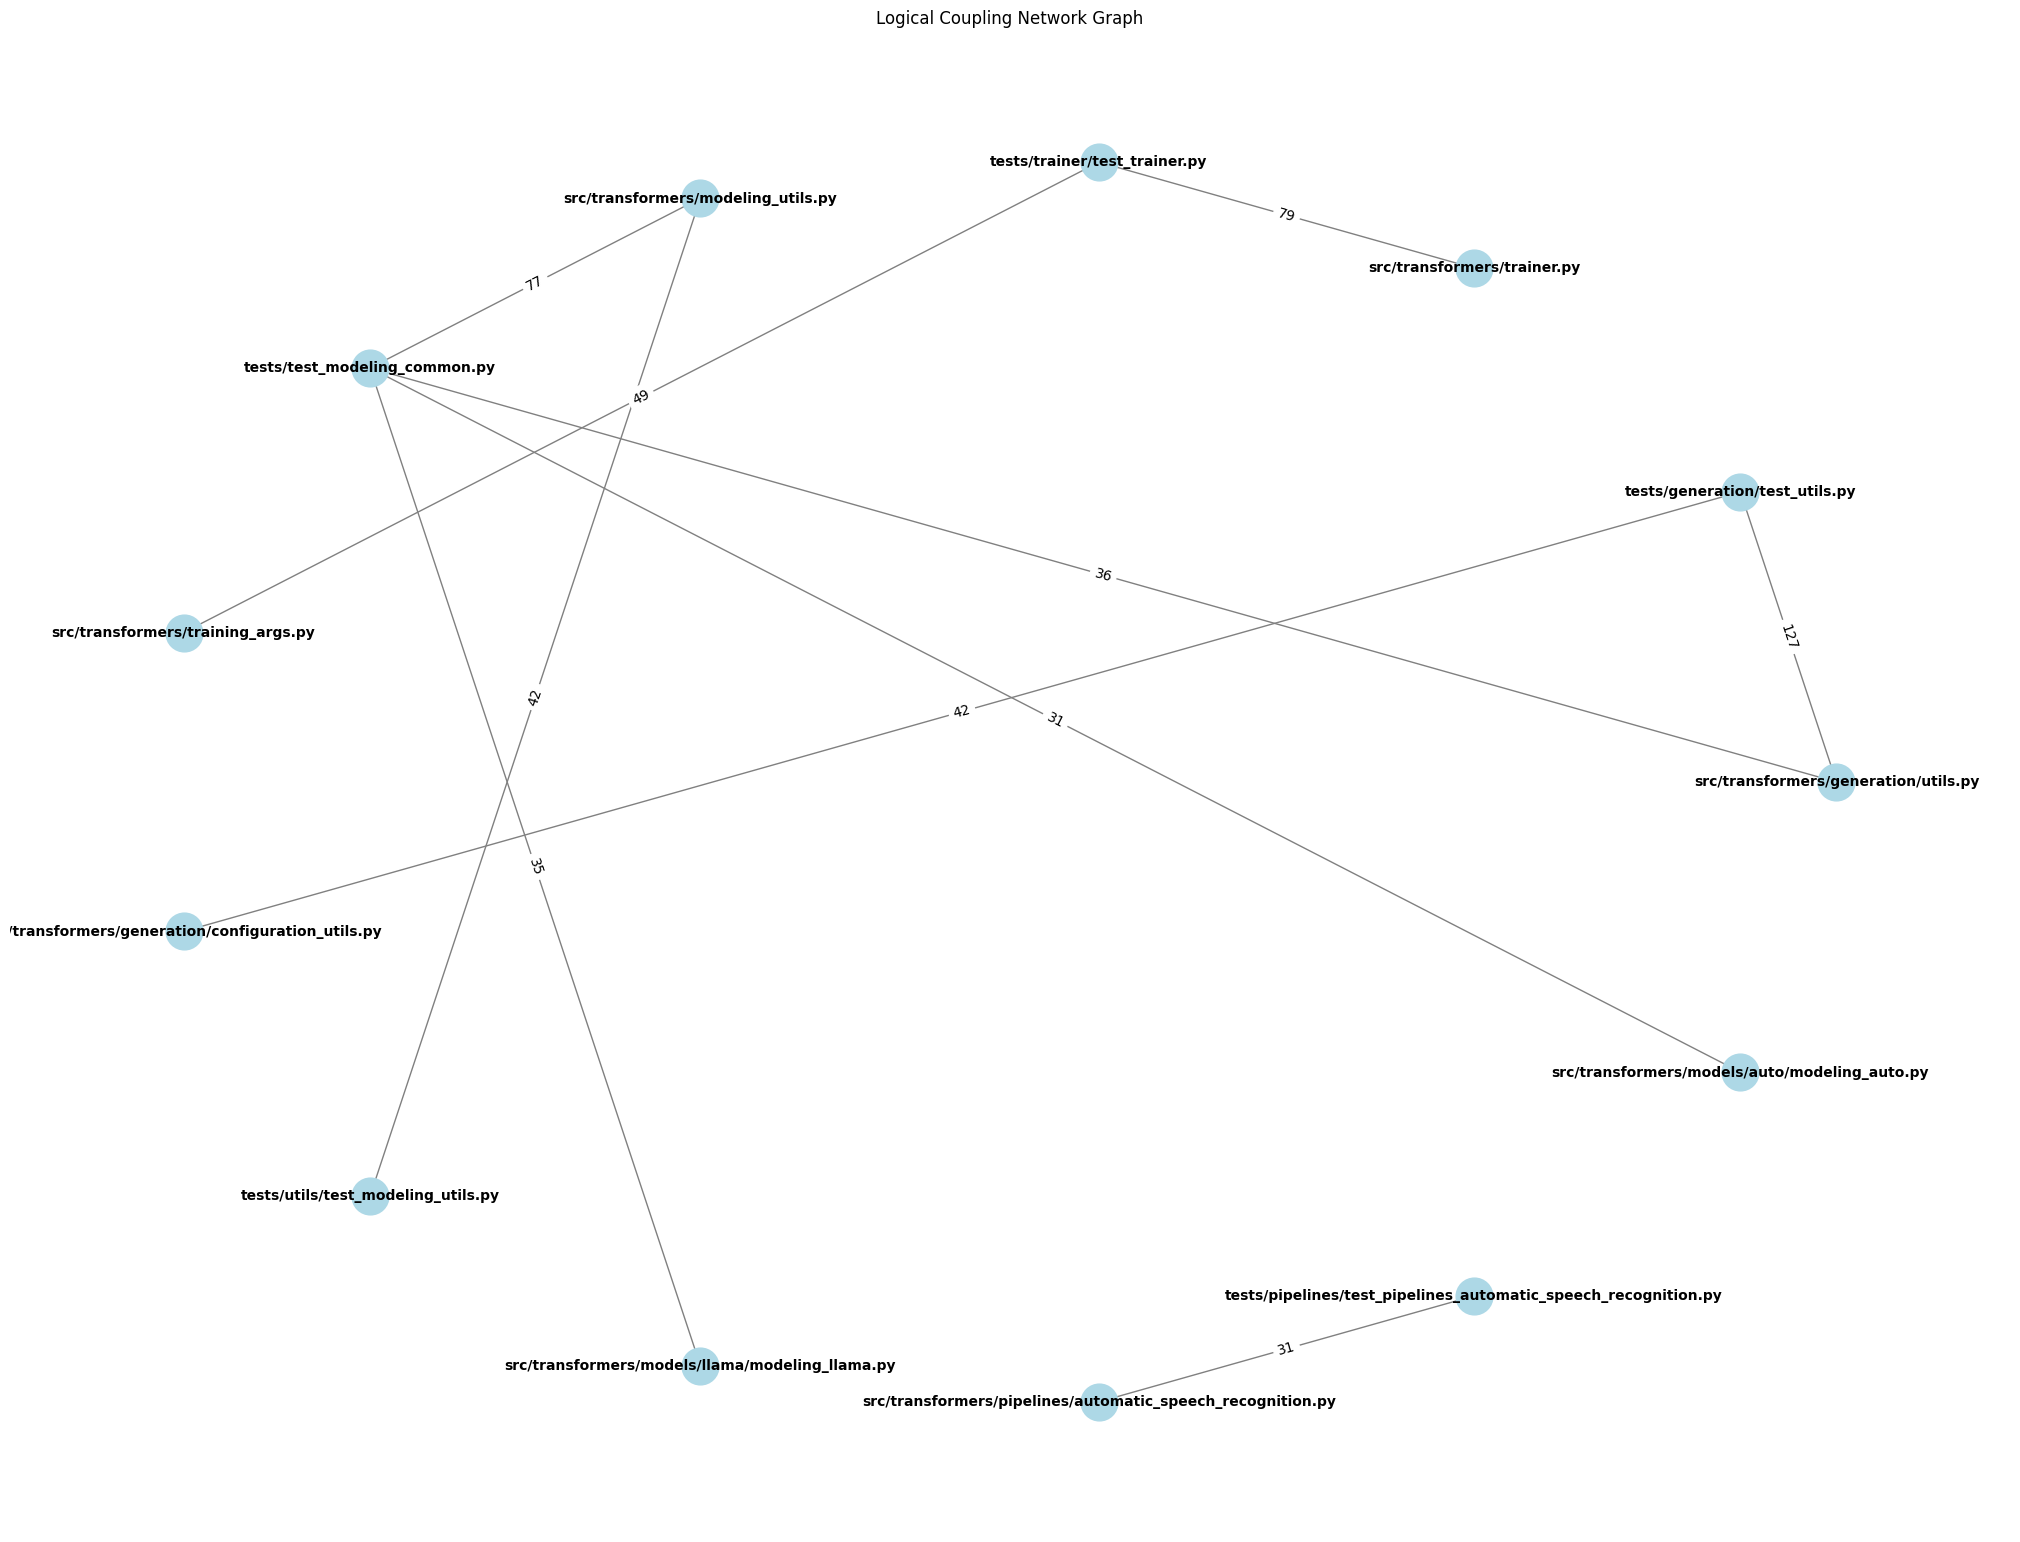

In [3]:
from datetime import datetime
from pydriller import Repository
from collections import Counter
import itertools
import os
from utils import plot_network_graph

REPOSITORY = os.environ.get("REPOSITORY_PATH")
if REPOSITORY is None:
    raise ValueError("Please source the setup.sh script or set the REPOSITORY_PATH environment variable to the local path of the cloned repository.")

DATE = datetime(2023, 1, 1)

def calculate_logical_coupling(repository, since_date):
    print("Analyzing repo...")
    file_pair_coupling = Counter()

    for commit in Repository(repository, since=since_date).traverse_commits():
        # Consider only Python files for coupling analysis, __init__.py files are excluded
        modified_files = [
            file.new_path for file in commit.modified_files
            if file.new_path and file.new_path.endswith('.py') and
               os.path.basename(file.new_path) != "__init__.py"
        ]
        # Commit requires at least two modified files to form a pair
        if len(modified_files) < 2:
            continue

        file_pairs = itertools.combinations(modified_files, 2)
        test_pairs = [
            pair for pair in file_pairs
            if (os.path.basename(pair[0]).startswith('test_') and not os.path.basename(pair[1]).startswith('test_')) or
               (os.path.basename(pair[1]).startswith('test_') and not os.path.basename(pair[0]).startswith('test_'))
        ]
        file_pair_coupling.update([tuple(sorted(pair)) for pair in test_pairs])

    return file_pair_coupling

calculated_coupling = calculate_logical_coupling(REPOSITORY, DATE) # This might take a while
top_10_pairs = calculated_coupling.most_common(10)
top_10_pairs = [(pair[0], pair[1], count) for pair, count in top_10_pairs]
plot_network_graph(top_10_pairs, "TASK3_test_logical_coupling.png", (20,15))


## Implementation for Finding Corresponding Test Files:

### Strategy 1: Matching based on project structure:

In [26]:
import os

REPOSITORY = os.environ.get("REPOSITORY_PATH")
if REPOSITORY is None:
    raise ValueError("Please source the setup.sh script or set the REPOSITORY_PATH environment variable to the local path of the cloned repository.")

def get_corresponding_test_file(repository, file_path):
    test_filename = f"test_{os.path.basename(file_path)}"
    relative_src_path = os.path.relpath(file_path, start=os.path.join("src", "transformers"))
    relative_src_path_dir = os.path.dirname(relative_src_path)
    test_file_path = os.path.join('tests', relative_src_path_dir, test_filename)

    if not os.path.exists(os.path.join(repository, test_file_path)):
        raise FileNotFoundError(f"Test file {test_file_path} does not exist.")
    return test_file_path

example_file = os.path.join("src" , "transformers", "generation", "utils.py")
print(f"For example file: {example_file}")
print(f"Corresponding test file: {get_corresponding_test_file(REPOSITORY, example_file)}")

For example file: src/transformers/generation/utils.py
Corresponding test file: tests/generation/test_utils.py


### Strategy 2: Matching based on logical coupling:

In [42]:
from datetime import datetime
from pydriller import Repository
from collections import Counter
import itertools
import os

REPOSITORY = os.environ.get("REPOSITORY_PATH")
if REPOSITORY is None:
    raise ValueError("Please source the setup.sh script or set the REPOSITORY_PATH environment variable to the local path of the cloned repository.")

DATE = datetime(2023, 1, 1)

def get_corresponding_test_file(repository, since_date, file_path):
    file_pair_coupling = Counter()

    for commit in Repository(repository, since=since_date).traverse_commits():
        # Consider only Python files for coupling analysis, __init__.py files are excluded
        modified_files = {
            file.new_path for file in commit.modified_files
            if file.new_path and file.new_path.endswith('.py') and
               os.path.basename(file.new_path) != "__init__.py"
        }

        # Skipt irrelevant commits
        if file_path not in modified_files:
            continue
        if len(modified_files) < 2:
            continue

        file_pairs = itertools.combinations(modified_files, 2)
        test_pairs = [
            pair for pair in file_pairs
            if (os.path.basename(pair[0]).startswith('test_') and pair[1] == file_path) or
               (os.path.basename(pair[1]).startswith('test_') and pair[0] == file_path)
        ]
        file_pair_coupling.update([tuple(sorted(pair)) for pair in test_pairs])

    most_common = file_pair_coupling.most_common(1)
    if not most_common:
        raise ValueError(f"No coupled test file found for {file_path}.")
    pair = most_common[0][0]
    if os.path.basename(pair[1]).startswith('test_'):
        return pair[1]
    return pair[0]

example_file = os.path.join("src" , "transformers", "generation", "utils.py")
print(f"For example file: {example_file}")
print(f"Corresponding test file: {get_corresponding_test_file(REPOSITORY, DATE, example_file)}")

For example file: src/transformers/generation/utils.py
Corresponding test file: tests/generation/test_utils.py
